In [ ]:
import os
import zipfile
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'archive (3).zip', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import zipfile

print("Is valid ZIP:", zipfile.is_zipfile(zip_path))

Is valid ZIP: True


In [ ]:
import zipfile

zip_path = "/content/archive (4).zip"
extract_path = "/content/soil_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/soil_dataset"))

['Dataset']


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root)

/content/soil_dataset
/content/soil_dataset/Dataset
/content/soil_dataset/Dataset/test
/content/soil_dataset/Dataset/test/Black Soil
/content/soil_dataset/Dataset/test/Clay soil
/content/soil_dataset/Dataset/test/Alluvial soil
/content/soil_dataset/Dataset/test/Red soil
/content/soil_dataset/Dataset/Train
/content/soil_dataset/Dataset/Train/Black Soil
/content/soil_dataset/Dataset/Train/Clay soil
/content/soil_dataset/Dataset/Train/Alluvial soil
/content/soil_dataset/Dataset/Train/Red soil


In [ ]:
for path in Path(extract_path).rglob("*"):
    if path.is_dir():
        print(path)

/content/soil_dataset/Dataset
/content/soil_dataset/Dataset/test
/content/soil_dataset/Dataset/Train
/content/soil_dataset/Dataset/test/Black Soil
/content/soil_dataset/Dataset/test/Clay soil
/content/soil_dataset/Dataset/test/Alluvial soil
/content/soil_dataset/Dataset/test/Red soil
/content/soil_dataset/Dataset/Train/Black Soil
/content/soil_dataset/Dataset/Train/Clay soil
/content/soil_dataset/Dataset/Train/Alluvial soil
/content/soil_dataset/Dataset/Train/Red soil


In [ ]:
train_dir = Path("/content/soil_dataset/Dataset/Train")
test_dir = Path("/content/soil_dataset/Dataset/test")

In [ ]:
train_classes = [
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
]

test_classes = [
    folder.name
    for folder in test_dir.iterdir()
    if folder.is_dir()
]

print("Training classes:")
print(train_classes)

print("\nTest classes:")
print(test_classes)

Training classes:
['Black Soil', 'Clay soil', 'Alluvial soil', 'Red soil']

Test classes:
['Black Soil', 'Clay soil', 'Alluvial soil', 'Red soil']


In [ ]:
print(set(train_classes) == set(test_classes))

True


In [ ]:
train_counts = {}

for class_name in train_classes:
    class_path = train_dir / class_name

    images = [
        f for f in class_path.iterdir()
        if f.is_file()
    ]

    train_counts[class_name] = len(images)

train_counts

{'Black Soil': 231, 'Clay soil': 199, 'Alluvial soil': 528, 'Red soil': 264}

In [ ]:
test_counts = {}

for class_name in test_classes:
    class_path = test_dir / class_name

    images = [
        f for f in class_path.iterdir()
        if f.is_file()
    ]

    test_counts[class_name] = len(images)

test_counts

{'Black Soil': 116, 'Clay soil': 65, 'Alluvial soil': 54, 'Red soil': 106}

In [ ]:
image_summary = pd.DataFrame({
    "Class": train_classes,
    "Train": [train_counts[c] for c in train_classes],
    "Test": [test_counts[c] for c in train_classes]
})

image_summary["Total"] = (
    image_summary["Train"] +
    image_summary["Test"]
)

image_summary

,Class,Train,Test,Total
0,Black Soil,231,116,347
1,Clay soil,199,65,264
2,Alluvial soil,528,54,582
3,Red soil,264,106,370


In [ ]:
image_summary["Percentage"] = (
    image_summary["Total"] /
    image_summary["Total"].sum() * 100
)

image_summary

,Class,Train,Test,Total,Percentage
0,Black Soil,231,116,347,22.200896
1,Clay soil,199,65,264,16.890595
2,Alluvial soil,528,54,582,37.236084
3,Red soil,264,106,370,23.672425


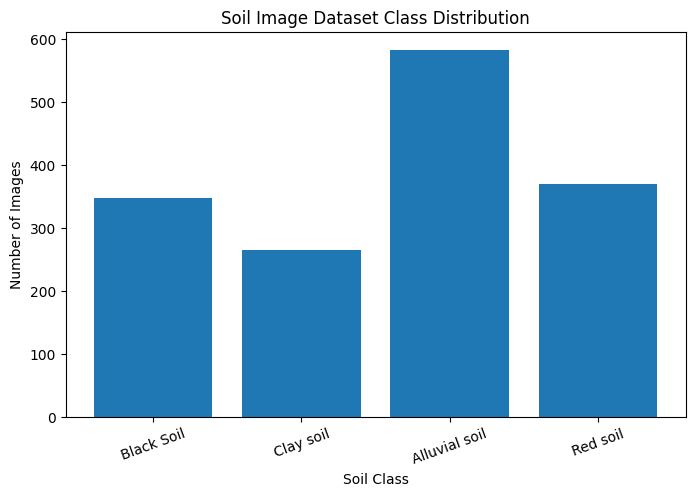

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    image_summary["Class"],
    image_summary["Total"]
)

plt.xlabel("Soil Class")
plt.ylabel("Number of Images")
plt.title("Soil Image Dataset Class Distribution")

plt.xticks(rotation=20)

plt.show()

In [ ]:
from collections import Counter

extensions = Counter()

valid_extensions = [".jpg", ".jpeg", ".png", ".webp", ".gif"]

for file in Path(extract_path).rglob("*"):
    if file.is_file() and file.suffix.lower() in valid_extensions:
        extensions[file.suffix.lower()] += 1

print(extensions)

Counter({'.jpg': 1424, '.jpeg': 122, '.webp': 7, '.png': 7, '.gif': 3})


In [ ]:
print("Total images:", sum(extensions.values()))

Total images: 1563


In [ ]:
format_table = pd.DataFrame(
    list(extensions.items()),
    columns=["Image Format", "Number of Images"]
)

format_table

,Image Format,Number of Images
0,.jpg,1424
1,.webp,7
2,.jpeg,122
3,.png,7
4,.gif,3


In [ ]:
format_table["Percentage"] = (
    format_table["Number of Images"] /
    format_table["Number of Images"].sum() * 100
)

format_table

,Image Format,Number of Images,Percentage
0,.jpg,1424,91.106846
1,.webp,7,0.447857
2,.jpeg,122,7.805502
3,.png,7,0.447857
4,.gif,3,0.191939


In [ ]:
image_sizes = []

for file in Path(extract_path).rglob("*"):

    if file.is_file() and file.suffix.lower() in valid_extensions:

        try:
            with Image.open(file) as img:
                image_sizes.append(img.size)

        except Exception:
            pass

print("Images successfully checked:", len(image_sizes))
print("Number of unique image sizes:", len(set(image_sizes)))

Images successfully checked: 1563
Number of unique image sizes: 190


In [ ]:
size_counts = Counter(image_sizes)

print("Most common image sizes:")

for size, count in size_counts.most_common(10):
    print(size, "->", count)

Most common image sizes:
(1160, 522) -> 312
(275, 183) -> 188
(728, 728) -> 171
(225, 225) -> 89
(100, 100) -> 85
(259, 194) -> 58
(262, 192) -> 24
(265, 190) -> 24
(276, 183) -> 20
(390, 280) -> 20


In [ ]:
bad_images = []

for file in Path(extract_path).rglob("*"):

    if file.is_file() and file.suffix.lower() in valid_extensions:

        try:
            with Image.open(file) as img:
                img.verify()

        except Exception as e:
            bad_images.append({
                "file": str(file),
                "error": str(e)
            })

print("Corrupted/unreadable images:", len(bad_images))

Corrupted/unreadable images: 0


In [ ]:
import hashlib

hashes = {}
duplicates = []

for file in Path(extract_path).rglob("*"):

    if file.is_file() and file.suffix.lower() in valid_extensions:

        try:
            with open(file, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hashes:
                duplicates.append({
                    "original": hashes[file_hash],
                    "duplicate": str(file)
                })
            else:
                hashes[file_hash] = str(file)

        except Exception:
            pass

print("Duplicate images:", len(duplicates))

Duplicate images: 890


In [ ]:
print("Training folders:")
for folder in sorted(train_dir.iterdir()):
    if folder.is_dir():
        print("-", folder.name)

print("\nTesting folders:")
for folder in sorted(test_dir.iterdir()):
    if folder.is_dir():
        print("-", folder.name)

Training folders:
- Alluvial soil
- Black Soil
- Clay soil
- Red soil

Testing folders:
- Alluvial soil
- Black Soil
- Clay soil
- Red soil


In [ ]:
import hashlib
from pathlib import Path

hash_locations = {}

for file in Path(extract_path).rglob("*"):

    if file.is_file() and file.suffix.lower() in valid_extensions:

        try:
            with open(file, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash not in hash_locations:
                hash_locations[file_hash] = []

            hash_locations[file_hash].append(str(file))

        except Exception:
            pass


# Analyze duplicate groups
same_train = 0
same_test = 0
train_test_duplicates = 0

for locations in hash_locations.values():

    if len(locations) > 1:

        train_files = [x for x in locations if "/Train/" in x or "\\Train\\" in x]
        test_files = [x for x in locations if "/Test/" in x or "\\Test\\" in x]

        if len(train_files) > 1:
            same_train += 1

        if len(test_files) > 1:
            same_test += 1

        if train_files and test_files:
            train_test_duplicates += 1


print("Duplicate groups within training:", same_train)
print("Duplicate groups within testing:", same_test)
print("Duplicate groups across train and test:", train_test_duplicates)

Duplicate groups within training: 480
Duplicate groups within testing: 0
Duplicate groups across train and test: 0


In [ ]:
from collections import defaultdict

hash_classes = defaultdict(set)

for file in Path(extract_path).rglob("*"):

    if file.is_file() and file.suffix.lower() in valid_extensions:

        try:
            with open(file, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            class_name = file.parent.name
            hash_classes[file_hash].add(class_name)

        except Exception:
            pass


different_label_duplicates = []

for file_hash, classes in hash_classes.items():

    if len(classes) > 1:
        different_label_duplicates.append(
            (file_hash, classes)
        )

print(
    "Duplicate groups with different labels:",
    len(different_label_duplicates)
)

Duplicate groups with different labels: 1


In [ ]:
for file_hash, classes in different_label_duplicates:

    print("Hash:", file_hash)
    print("Classes:", classes)

    print("\nFiles:")

    for file in Path(extract_path).rglob("*"):

        if file.is_file() and file.suffix.lower() in valid_extensions:

            try:
                with open(file, "rb") as f:
                    current_hash = hashlib.md5(f.read()).hexdigest()

                if current_hash == file_hash:
                    print(file)

            except Exception:
                pass

    print("\n" + "-" * 60)

Hash: 3df7a5aa9137acf6d2424347711b32b0
Classes: {'Black Soil', 'Alluvial soil'}

Files:
/content/soil_dataset/Dataset/Train/Black Soil/Copy of images386.jpg
/content/soil_dataset/Dataset/Train/Black Soil/images386.jpg
/content/soil_dataset/Dataset/Train/Alluvial soil/Copy of images386.jpg
/content/soil_dataset/Dataset/test/Black Soil/images386.jpg

------------------------------------------------------------


In [ ]:
from collections import defaultdict

hash_locations = defaultdict(list)

for file in Path(extract_path).rglob("*"):

    if file.is_file() and file.suffix.lower() in valid_extensions:

        try:
            with open(file, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_locations[file_hash].append(str(file))

        except Exception:
            pass


train_test_duplicates = []

for file_hash, locations in hash_locations.items():

    train_files = []
    test_files = []

    for location in locations:

        path_lower = location.lower()

        if "/train/" in path_lower:
            train_files.append(location)

        elif "/test/" in path_lower:
            test_files.append(location)

    if train_files and test_files:

        train_test_duplicates.append({
            "hash": file_hash,
            "train_files": train_files,
            "test_files": test_files
        })


print("Train-Test duplicate groups:", len(train_test_duplicates))

for item in train_test_duplicates:
    print("\nHash:", item["hash"])

    print("Train:")
    for f in item["train_files"]:
        print(" ", f)

    print("Test:")
    for f in item["test_files"]:
        print(" ", f)

Train-Test duplicate groups: 295

Hash: 785ba958acb2abe920b40212e8aa3f7f
Train:
  /content/soil_dataset/Dataset/Train/Black Soil/Black_27.jpg
Test:
  /content/soil_dataset/Dataset/test/Black Soil/Black_27.jpg

Hash: d2d35225a190d44ae439ae0d54c135a4
Train:
  /content/soil_dataset/Dataset/Train/Black Soil/Copy of images267.jpg
  /content/soil_dataset/Dataset/Train/Black Soil/images267.jpg
  /content/soil_dataset/Dataset/Train/Black Soil/Copy of images267(1).jpg
Test:
  /content/soil_dataset/Dataset/test/Black Soil/images267.jpg
  /content/soil_dataset/Dataset/test/Black Soil/Copy of images267(1).jpg

Hash: 2e579d8dbdec1a740a3bd5006da57da1
Train:
  /content/soil_dataset/Dataset/Train/Black Soil/Sample7.0.jpg
  /content/soil_dataset/Dataset/Train/Black Soil/Copy of Copy of Sample7.0.jpg
  /content/soil_dataset/Dataset/Train/Black Soil/Copy of Sample7.0.jpg
Test:
  /content/soil_dataset/Dataset/test/Black Soil/Copy of Sample7.0.jpg

Hash: 00600abafe1bf3a70e10970b372005b6
Train:
  /content/s

In [ ]:
import os
os.listdir('/content')

['.config',
 '.ipynb_checkpoints',
 'soil_dataset',
 'archive (4).zip',
 'archive (3).zip',
 'sample_data']

In [ ]:
import os

dataset_path = "/content/soil_dataset/Dataset"

print("Classes/folders:")
print(os.listdir(dataset_path))

Classes/folders:
['test', 'Train']


In [ ]:
import os

dataset_path = "/content/soil_dataset/Dataset"

train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "test")

print("Train classes:")
print(os.listdir(train_path))

print("\nTest classes:")
print(os.listdir(test_path))

Train classes:
['Black Soil', 'Clay soil', 'Alluvial soil', 'Red soil']

Test classes:
['Black Soil', 'Clay soil', 'Alluvial soil', 'Red soil']


In [ ]:
from collections import Counter

def count_images(folder):
    counts = {}

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

    return counts

train_counts = count_images(train_path)
test_counts = count_images(test_path)

print("TRAIN DATA")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nTEST DATA")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

print("\nTOTAL")
print("Train:", sum(train_counts.values()))
print("Test:", sum(test_counts.values()))
print("Overall:", sum(train_counts.values()) + sum(test_counts.values()))

TRAIN DATA
Black Soil: 231
Clay soil: 199
Alluvial soil: 528
Red soil: 264

TEST DATA
Black Soil: 116
Clay soil: 65
Alluvial soil: 54
Red soil: 106

TOTAL
Train: 1222
Test: 341
Overall: 1563


In [ ]:
from collections import Counter

extensions = Counter()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        extensions[ext] += 1

print("Image/file formats:")
for ext, count in extensions.items():
    print(ext, ":", count)

Image/file formats:
.jpg : 1424
.jpeg : 122
.png : 7
.webp : 7
.gif : 3


In [ ]:
from PIL import Image
import os
from collections import Counter

dimensions = Counter()
corrupted = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            with Image.open(file_path) as img:
                dimensions[img.size] += 1
        except Exception:
            corrupted.append(file_path)

print("Total images checked:", sum(dimensions.values()))
print("Unique image dimensions:", len(dimensions))

print("\nMost common dimensions:")
for size, count in dimensions.most_common(10):
    print(size, ":", count)

print("\nCorrupted/unreadable images:", len(corrupted))

Total images checked: 1563
Unique image dimensions: 190

Most common dimensions:
(1160, 522) : 312
(275, 183) : 188
(728, 728) : 171
(225, 225) : 89
(100, 100) : 85
(259, 194) : 58
(262, 192) : 24
(265, 190) : 24
(276, 183) : 20
(390, 280) : 20

Corrupted/unreadable images: 0


In [ ]:
import os
import hashlib
from collections import defaultdict

def get_image_hash(file_path):
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()


hashes = defaultdict(list)

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            image_hash = get_image_hash(file_path)
            hashes[image_hash].append(file_path)
        except Exception:
            pass


duplicate_groups = {
    h: paths for h, paths in hashes.items()
    if len(paths) > 1
}

print("Total unique images:", len(hashes))
print("Duplicate groups:", len(duplicate_groups))

duplicate_files = sum(len(paths) - 1 for paths in duplicate_groups.values())

print("Duplicate occurrences:", duplicate_files)

Total unique images: 673
Duplicate groups: 622
Duplicate occurrences: 890


In [ ]:
import os
import hashlib

train_path = "/content/soil_dataset/Dataset/Train"
test_path = "/content/soil_dataset/Dataset/test"


def get_hash(file_path):
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()


train_hashes = {}
test_hashes = {}

# Train hashes
for root, dirs, files in os.walk(train_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            h = get_hash(path)
            train_hashes.setdefault(h, []).append(path)
        except:
            pass

# Test hashes
for root, dirs, files in os.walk(test_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            h = get_hash(path)
            test_hashes.setdefault(h, []).append(path)
        except:
            pass


# Find hashes present in both
common_hashes = set(train_hashes.keys()) & set(test_hashes.keys())

print("Unique Train images:", len(train_hashes))
print("Unique Test images:", len(test_hashes))
print("Train-Test duplicate groups:", len(common_hashes))

Unique Train images: 673
Unique Test images: 295
Train-Test duplicate groups: 295


In [ ]:
from collections import defaultdict
import os
import hashlib

image_labels = defaultdict(list)

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            h = get_hash(path)

            # Get class name from folder
            class_name = os.path.basename(os.path.dirname(path))

            image_labels[h].append((class_name, path))

        except:
            pass


# Find images that have multiple labels
conflicting_labels = {}

for h, entries in image_labels.items():
    labels = set(label for label, path in entries)

    if len(labels) > 1:
        conflicting_labels[h] = entries


print("Images with conflicting labels:", len(conflicting_labels))

Images with conflicting labels: 1


In [ ]:
for h, entries in list(conflicting_labels.items())[:20]:

    print("\nHash:", h)

    for label, path in entries:
        print("Label:", label)
        print("File :", path)


Hash: 3df7a5aa9137acf6d2424347711b32b0
Label: Black Soil
File : /content/soil_dataset/Dataset/test/Black Soil/images386.jpg
Label: Black Soil
File : /content/soil_dataset/Dataset/Train/Black Soil/Copy of images386.jpg
Label: Black Soil
File : /content/soil_dataset/Dataset/Train/Black Soil/images386.jpg
Label: Alluvial soil
File : /content/soil_dataset/Dataset/Train/Alluvial soil/Copy of images386.jpg


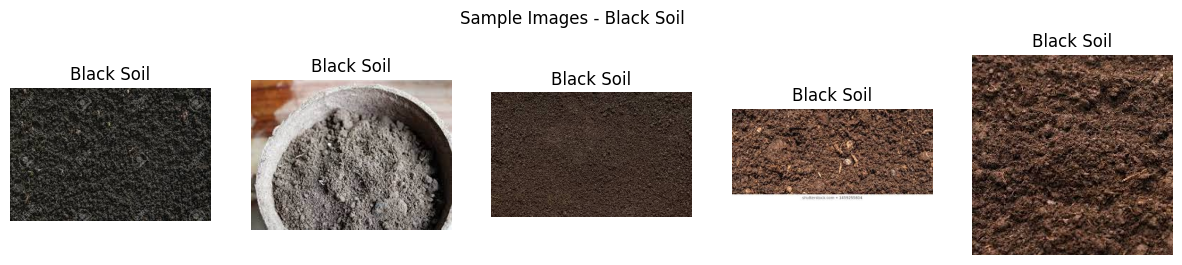

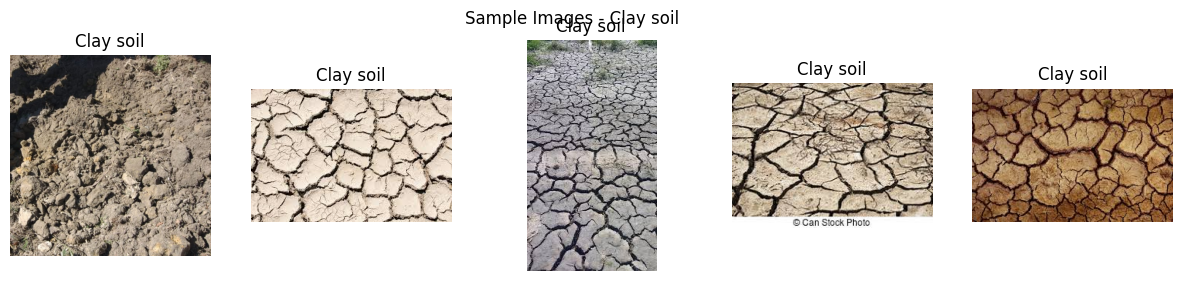

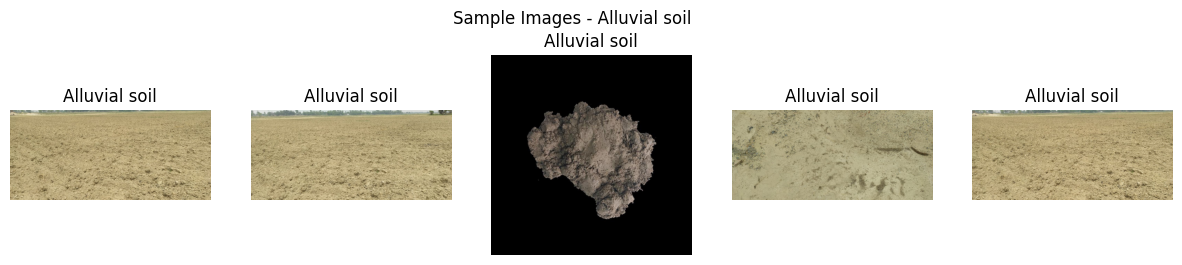

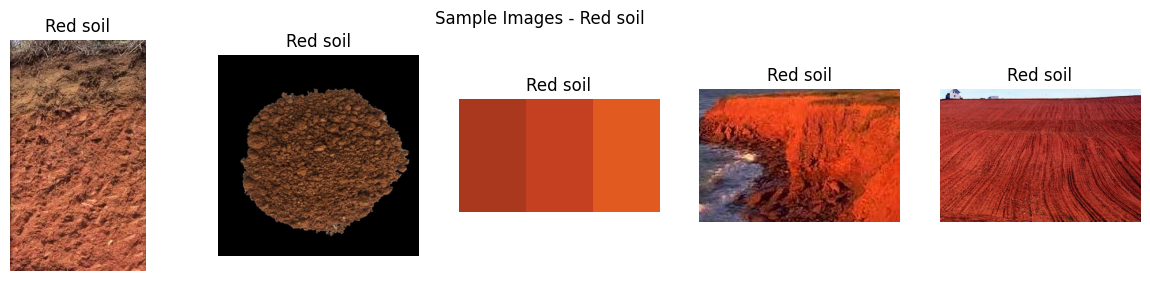

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_path)

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".gif"))
    ]

    samples = random.sample(images, min(5, len(images)))

    plt.figure(figsize=(15, 3))

    for i, image_name in enumerate(samples):
        image_path = os.path.join(class_path, image_name)

        try:
            img = Image.open(image_path).convert("RGB")

            plt.subplot(1, 5, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(class_name)

        except Exception:
            pass

    plt.suptitle(f"Sample Images - {class_name}")
    plt.show()

In [ ]:
import os

processed_path = "/content/soil_dataset/processed"

os.makedirs(processed_path, exist_ok=True)

print("Processed folder created!")

Processed folder created!


In [ ]:
import os
import hashlib
import shutil
from collections import defaultdict

from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Paths
# --------------------------------------------------

raw_dataset = "/content/soil_dataset/Dataset"
processed_dataset = "/content/soil_dataset/processed"

train_raw = os.path.join(raw_dataset, "Train")
test_raw = os.path.join(raw_dataset, "test")

# --------------------------------------------------
# Supported image formats
# --------------------------------------------------

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".gif"
)

# --------------------------------------------------
# MD5 hash function
# --------------------------------------------------

def get_hash(file_path):
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()


# --------------------------------------------------
# Collect all images from Train + Test
# --------------------------------------------------

all_images = []

for split_folder in [train_raw, test_raw]:

    for class_name in os.listdir(split_folder):

        class_path = os.path.join(split_folder, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            if file_name.lower().endswith(image_extensions):

                file_path = os.path.join(class_path, file_name)

                all_images.append({
                    "path": file_path,
                    "label": class_name
                })


print("Total raw images:", len(all_images))


# --------------------------------------------------
# Group images by MD5 hash
# --------------------------------------------------

hash_groups = defaultdict(list)

for item in all_images:

    try:
        image_hash = get_hash(item["path"])

        hash_groups[image_hash].append(item)

    except Exception as e:
        print("Could not read:", item["path"])


print("Unique image contents:", len(hash_groups))


# --------------------------------------------------
# Remove duplicate copies
# Keep only one copy when labels are consistent
# --------------------------------------------------

clean_images = []
conflicting_images = 0

for image_hash, items in hash_groups.items():

    labels = set(item["label"] for item in items)

    # Same image has different labels
    if len(labels) > 1:

        conflicting_images += len(items)
        continue

    # Same image duplicated with same label
    # Keep only one copy
    clean_images.append(items[0])


print("Images after deduplication:", len(clean_images))
print("Images removed because of conflicting labels:", conflicting_images)

Total raw images: 1563
Unique image contents: 673
Images after deduplication: 672
Images removed because of conflicting labels: 4


In [ ]:
from collections import Counter

class_counts = Counter(
    item["label"] for item in clean_images
)

print("Clean dataset class distribution:\n")

for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")

print("\nTotal:", len(clean_images))

Clean dataset class distribution:

Alluvial soil: 281
Black Soil: 122
Clay soil: 114
Red soil: 155

Total: 672


In [ ]:
# Get paths and labels

paths = [item["path"] for item in clean_images]
labels = [item["label"] for item in clean_images]


# First: 70% train, 30% temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)


# Second: split temporary into 15% validation and 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)


print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))
print("Total:", len(train_paths) + len(val_paths) + len(test_paths))

Train: 470
Validation: 101
Test: 101
Total: 672


In [ ]:
splits = {
    "train": (train_paths, train_labels),
    "val": (val_paths, val_labels),
    "test": (test_paths, test_labels)
}

classes = sorted(set(labels))

for split in splits:

    for class_name in classes:

        folder = os.path.join(
            processed_dataset,
            split,
            class_name
        )

        os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
for split, (split_paths, split_labels) in splits.items():

    for source_path, label in zip(split_paths, split_labels):

        file_name = os.path.basename(source_path)

        destination_folder = os.path.join(
            processed_dataset,
            split,
            label
        )

        destination_path = os.path.join(
            destination_folder,
            file_name
        )

        shutil.copy2(source_path, destination_path)


print("Images copied successfully!")

Images copied successfully!


In [ ]:
for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    total = 0

    for class_name in classes:

        folder = os.path.join(
            processed_dataset,
            split,
            class_name
        )

        count = len(os.listdir(folder))

        print(f"{class_name}: {count}")

        total += count

    print("Total:", total)


TRAIN
Alluvial soil: 197
Black Soil: 85
Clay soil: 80
Red soil: 108
Total: 470

VAL
Alluvial soil: 42
Black Soil: 18
Clay soil: 17
Red soil: 24
Total: 101

TEST
Alluvial soil: 42
Black Soil: 19
Clay soil: 17
Red soil: 23
Total: 101


In [ ]:
import os
import hashlib

def image_hash(path):
    md5 = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()


split_hashes = {}

for split in ["train", "val", "test"]:

    split_hashes[split] = set()

    split_path = os.path.join(processed_dataset, split)

    for root, dirs, files in os.walk(split_path):

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp", ".gif")
            ):

                path = os.path.join(root, file)

                try:
                    split_hashes[split].add(image_hash(path))
                except:
                    pass


train_val = split_hashes["train"] & split_hashes["val"]
train_test = split_hashes["train"] & split_hashes["test"]
val_test = split_hashes["val"] & split_hashes["test"]

print("Train-Val duplicates :", len(train_val))
print("Train-Test duplicates:", len(train_test))
print("Val-Test duplicates  :", len(val_test))

Train-Val duplicates : 0
Train-Test duplicates: 0
Val-Test duplicates  : 0


In [ ]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [ ]:
processed_dataset = "/content/soil_dataset/processed"

train_dataset = datasets.ImageFolder(
    root=f"{processed_dataset}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{processed_dataset}/val",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{processed_dataset}/test",
    transform=val_test_transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Train images: 469
Validation images: 101
Test images: 101


In [ ]:
print("Class names:")
print(train_dataset.classes)

print("\nClass to index:")
print(train_dataset.class_to_idx)

Class names:
['Alluvial soil', 'Black Soil', 'Clay soil', 'Red soil']

Class to index:
{'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}


In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([3, 2, 3, 1, 0, 0, 0, 0, 0, 1])


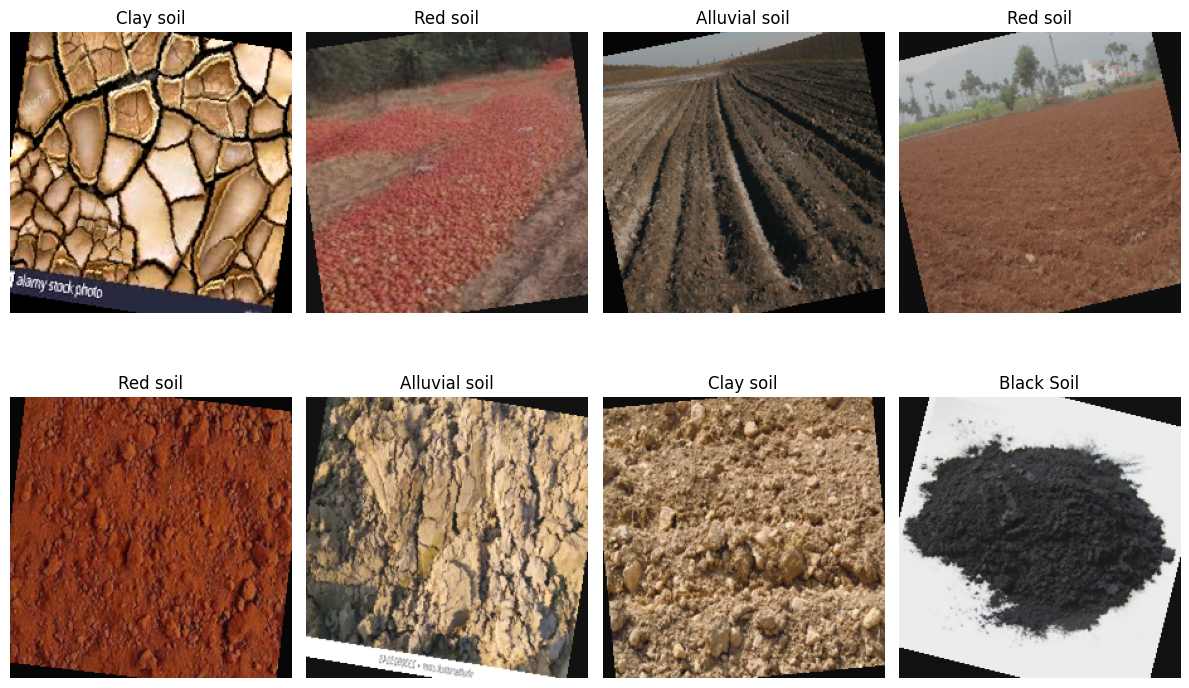

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    # Undo normalization for visualization
    img = images[i].permute(1, 2, 0)

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import zipfile
import os

zip_path = "/content/archive (4).zip"
extract_path = "/content/soil_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("/content/soil_dataset"))

['Dataset']


In [ ]:
print(os.listdir("/content/soil_dataset/Dataset"))

['Train', 'test']


In [ ]:
import os
import hashlib
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split

# -----------------------------
# Paths
# -----------------------------

raw_dataset = "/content/soil_dataset/Dataset"
processed_dataset = "/content/soil_dataset/processed"

train_raw = os.path.join(raw_dataset, "Train")
test_raw = os.path.join(raw_dataset, "test")

image_extensions = (".jpg", ".jpeg", ".png", ".webp", ".gif")


# -----------------------------
# MD5 hash function
# -----------------------------

def get_hash(file_path):
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()


# -----------------------------
# Collect all images
# -----------------------------

all_images = []

for split_folder in [train_raw, test_raw]:

    for class_name in os.listdir(split_folder):

        class_path = os.path.join(split_folder, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            if file_name.lower().endswith(image_extensions):

                all_images.append({
                    "path": os.path.join(class_path, file_name),
                    "label": class_name
                })

print("Total raw images:", len(all_images))


# -----------------------------
# Group identical images
# -----------------------------

hash_groups = defaultdict(list)

for item in all_images:

    try:
        h = get_hash(item["path"])
        hash_groups[h].append(item)

    except Exception as e:
        print("Could not read:", item["path"])


print("Unique image contents:", len(hash_groups))


# -----------------------------
# Remove duplicate copies
# Remove conflicting labels
# -----------------------------

clean_images = []
conflicting_groups = 0

for h, items in hash_groups.items():

    labels = set(item["label"] for item in items)

    # Same image has different labels
    if len(labels) > 1:
        conflicting_groups += 1
        continue

    # Keep only one copy of identical images
    clean_images.append(items[0])


print("Clean images:", len(clean_images))
print("Conflicting duplicate groups removed:", conflicting_groups)


# -----------------------------
# Get labels
# -----------------------------

paths = [item["path"] for item in clean_images]
labels = [item["label"] for item in clean_images]

print("\nClasses:", sorted(set(labels)))


# -----------------------------
# 70% Train / 15% Validation / 15% Test
# -----------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)


print("\nSplit sizes:")
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


# -----------------------------
# Create folders
# -----------------------------

classes = sorted(set(labels))

for split in ["train", "val", "test"]:

    for class_name in classes:

        folder = os.path.join(
            processed_dataset,
            split,
            class_name
        )

        os.makedirs(folder, exist_ok=True)


# -----------------------------
# Copy images
# -----------------------------

splits = {
    "train": (train_paths, train_labels),
    "val": (val_paths, val_labels),
    "test": (test_paths, test_labels)
}

for split, (split_paths, split_labels) in splits.items():

    for source_path, label in zip(split_paths, split_labels):

        file_name = os.path.basename(source_path)

        destination_folder = os.path.join(
            processed_dataset,
            split,
            label
        )

        destination_path = os.path.join(
            destination_folder,
            file_name
        )

        shutil.copy2(source_path, destination_path)


print("\nProcessed dataset created successfully!")

Total raw images: 1563
Unique image contents: 673
Clean images: 672
Conflicting duplicate groups removed: 1

Classes: ['Alluvial soil', 'Black Soil', 'Clay soil', 'Red soil']

Split sizes:
Train: 470
Validation: 101
Test: 101

Processed dataset created successfully!


In [ ]:
for split in ["train", "val", "test"]:

    print(f"\n===== {split.upper()} =====")

    total = 0

    for class_name in classes:

        folder = os.path.join(
            processed_dataset,
            split,
            class_name
        )

        count = len(os.listdir(folder))

        print(f"{class_name}: {count}")

        total += count

    print("Total:", total)


===== TRAIN =====
Alluvial soil: 197
Black Soil: 85
Clay soil: 80
Red soil: 108
Total: 470

===== VAL =====
Alluvial soil: 42
Black Soil: 18
Clay soil: 17
Red soil: 24
Total: 101

===== TEST =====
Alluvial soil: 42
Black Soil: 19
Clay soil: 17
Red soil: 23
Total: 101


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing created successfully!")

Image preprocessing created successfully!


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

processed_dataset = "/content/soil_dataset/processed"

train_dataset = datasets.ImageFolder(
    root=f"{processed_dataset}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{processed_dataset}/val",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{processed_dataset}/test",
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 469
Validation: 101
Test: 101


In [ ]:
print("Classes:")
print(train_dataset.classes)

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Classes:
['Alluvial soil', 'Black Soil', 'Clay soil', 'Red soil']

Class mapping:
{'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}


In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([1, 3, 2, 3, 0, 0, 1, 0, 0, 3])


In [ ]:
from collections import Counter

train_counts = Counter(train_dataset.targets)

print("Training class distribution:\n")

for class_index, count in sorted(train_counts.items()):
    class_name = train_dataset.classes[class_index]
    print(f"{class_name}: {count}")

Training class distribution:

Alluvial soil: 197
Black Soil: 85
Clay soil: 80
Red soil: 107


In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained ResNet-50
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print("ResNet-50 loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


ResNet-50 loaded successfully!


In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
num_classes = 4

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

In [ ]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


In [ ]:
import numpy as np

class_counts = np.bincount(train_dataset.targets)

print("Class counts:", class_counts)

Class counts: [197  85  80 107]


In [ ]:
class_weights = len(train_dataset) / (
    len(class_counts) * class_counts
)

print("Class weights:", class_weights)

Class weights: [0.59517766 1.37941176 1.465625   1.09579439]


In [ ]:
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Tensor weights:", class_weights)

Tensor weights: tensor([0.5952, 1.3794, 1.4656, 1.0958], device='cuda:0')


In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted CrossEntropyLoss created!")

Weighted CrossEntropyLoss created!


In [ ]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Optimizer created!")

Optimizer created!


In [ ]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 23516228
Trainable parameters: 8196


In [ ]:
num_epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # Store results

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 1.1747 | Train Acc: 59.06% | Val Loss: 0.9511 | Val Acc: 85.15%
Epoch [2/5] Train Loss: 0.8019 | Train Acc: 84.86% | Val Loss: 0.7349 | Val Acc: 83.17%
Epoch [3/5] Train Loss: 0.6351 | Train Acc: 85.07% | Val Loss: 0.6358 | Val Acc: 83.17%
Epoch [4/5] Train Loss: 0.5193 | Train Acc: 84.65% | Val Loss: 0.5596 | Val Acc: 83.17%
Epoch [5/5] Train Loss: 0.4366 | Train Acc: 89.34% | Val Loss: 0.4998 | Val Acc: 87.13%


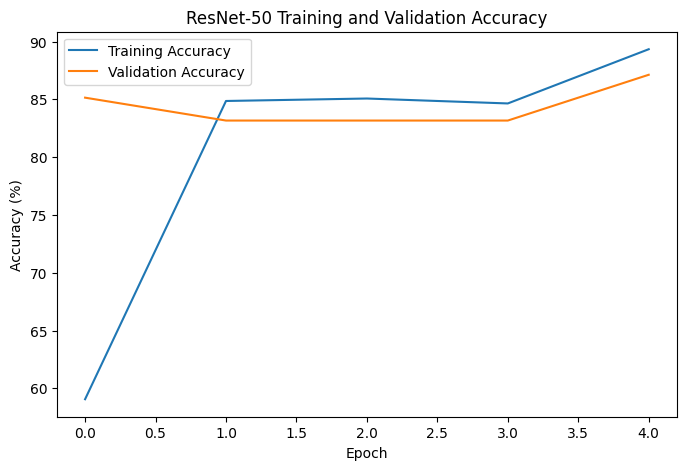

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-50 Training and Validation Accuracy")
plt.legend()
plt.show()

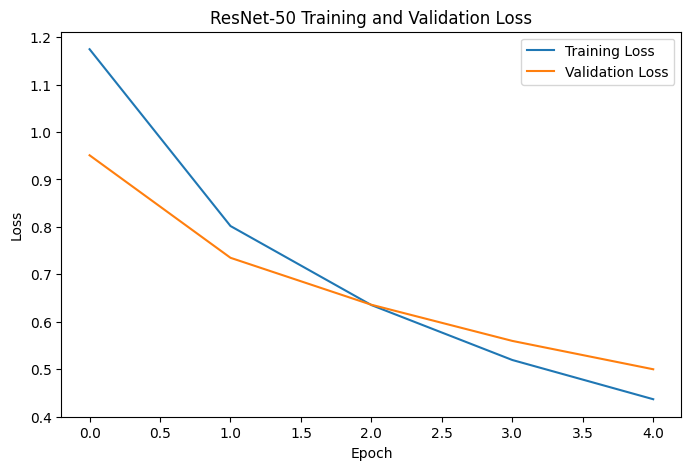

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
model_path = "/content/soil_dataset/resnet50_baseline.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/soil_dataset/resnet50_baseline.pth


In [ ]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions generated successfully!")
print("Number of test images:", len(all_labels))

Predictions generated successfully!
Number of test images: 101


In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 91.09%


In [ ]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-score:  {f1 * 100:.2f}%")

Precision: 91.46%
Recall:    91.09%
F1-score:  91.13%


In [ ]:
class_names = test_dataset.classes

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

Alluvial soil       0.95      0.88      0.91        42
   Black Soil       0.94      0.89      0.92        19
    Clay soil       0.79      0.88      0.83        17
     Red soil       0.92      1.00      0.96        23

     accuracy                           0.91       101
    macro avg       0.90      0.91      0.91       101
 weighted avg       0.91      0.91      0.91       101



<Figure size 700x700 with 0 Axes>

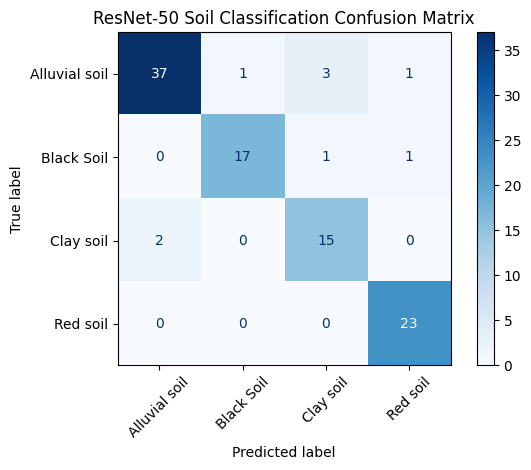

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    cmap="Blues"
)

plt.title("ResNet-50 Soil Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os

results_path = "/content/soil_dataset/resnet50_results.txt"

with open(results_path, "w") as f:

    f.write("ResNet-50 Soil Classification Results\n")
    f.write("=" * 45 + "\n\n")

    f.write(f"Test Accuracy: {accuracy * 100:.2f}%\n")
    f.write(f"Precision: {precision * 100:.2f}%\n")
    f.write(f"Recall: {recall * 100:.2f}%\n")
    f.write(f"F1-score: {f1 * 100:.2f}%\n")

print("Results saved:")
print(results_path)

Results saved:
/content/soil_dataset/resnet50_results.txt


In [ ]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep the final classification layer trainable
for param in model.fc.parameters():
    param.requires_grad = True

print("Fine-tuning layers:")
print("layer4 + fc")

Fine-tuning layers:
layer4 + fc


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Fine-tuning optimizer created!")

Fine-tuning optimizer created!


In [ ]:
num_epochs = 10

fine_train_losses = []
fine_val_losses = []

fine_train_accuracies = []
fine_val_accuracies = []

for epoch in range(num_epochs):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    fine_train_losses.append(train_loss)
    fine_val_losses.append(val_loss)

    fine_train_accuracies.append(train_accuracy)
    fine_val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.3372 | Train Acc: 90.62% | Val Loss: 0.2576 | Val Acc: 90.10%
Epoch [2/10] Train Loss: 0.1912 | Train Acc: 93.39% | Val Loss: 0.1821 | Val Acc: 96.04%
Epoch [3/10] Train Loss: 0.1161 | Train Acc: 95.74% | Val Loss: 0.1525 | Val Acc: 96.04%
Epoch [4/10] Train Loss: 0.0990 | Train Acc: 96.59% | Val Loss: 0.1463 | Val Acc: 97.03%
Epoch [5/10] Train Loss: 0.0605 | Train Acc: 98.29% | Val Loss: 0.1372 | Val Acc: 96.04%
Epoch [6/10] Train Loss: 0.0475 | Train Acc: 98.72% | Val Loss: 0.1316 | Val Acc: 95.05%
Epoch [7/10] Train Loss: 0.0276 | Train Acc: 99.36% | Val Loss: 0.1405 | Val Acc: 95.05%
Epoch [8/10] Train Loss: 0.0425 | Train Acc: 98.51% | Val Loss: 0.1752 | Val Acc: 95.05%
Epoch [9/10] Train Loss: 0.0439 | Train Acc: 98.29% | Val Loss: 0.1438 | Val Acc: 96.04%
Epoch [10/10] Train Loss: 0.0586 | Train Acc: 98.29% | Val Loss: 0.1282 | Val Acc: 95.05%


In [ ]:
fine_tuned_path = "/content/soil_dataset/resnet50_finetuned.pth"

torch.save(model.state_dict(), fine_tuned_path)

print("Fine-tuned model saved successfully!")
print(fine_tuned_path)

Fine-tuned model saved successfully!
/content/soil_dataset/resnet50_finetuned.pth


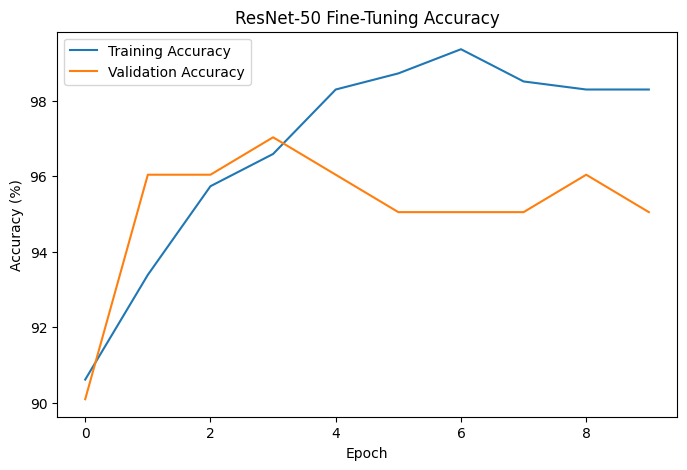

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    fine_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    fine_val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-50 Fine-Tuning Accuracy")
plt.legend()
plt.show()

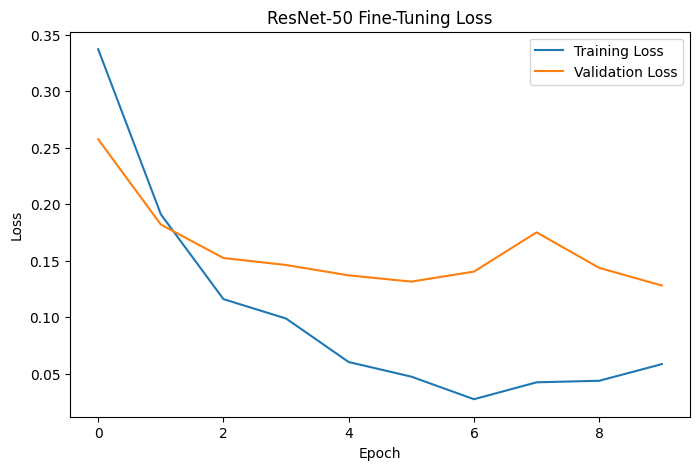

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_train_losses,
    label="Training Loss"
)

plt.plot(
    fine_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Fine-Tuning Loss")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:     {precision * 100:.2f}%")
print(f"Recall:        {recall * 100:.2f}%")
print(f"F1-score:      {f1 * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        zero_division=0
    )
)

Test Accuracy: 94.06%
Precision:     94.10%
Recall:        94.06%
F1-score:      94.06%

Classification Report:
               precision    recall  f1-score   support

Alluvial soil       0.95      0.95      0.95        42
   Black Soil       1.00      0.95      0.97        19
    Clay soil       0.82      0.82      0.82        17
     Red soil       0.96      1.00      0.98        23

     accuracy                           0.94       101
    macro avg       0.93      0.93      0.93       101
 weighted avg       0.94      0.94      0.94       101



Confusion Matrix:
[[40  0  2  0]
 [ 0 18  1  0]
 [ 2  0 14  1]
 [ 0  0  0 23]]


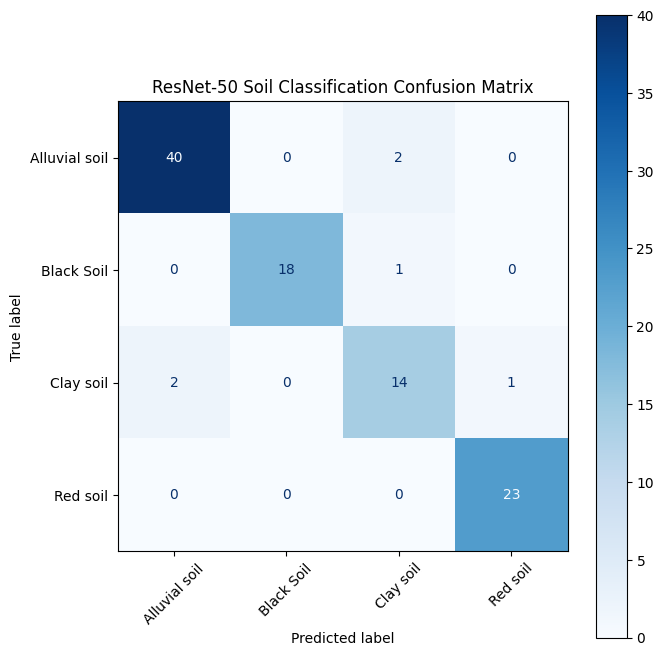

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

plt.title("ResNet-50 Soil Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
final_model_path = "/content/soil_dataset/resnet50_finetuned_final.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "num_classes": 4
}, final_model_path)

print("Final model saved successfully!")
print(final_model_path)

Final model saved successfully!
/content/soil_dataset/resnet50_finetuned_final.pth


In [ ]:
import json

history = {
    "train_loss": fine_train_losses,
    "val_loss": fine_val_losses,
    "train_accuracy": fine_train_accuracies,
    "val_accuracy": fine_val_accuracies
}

history_path = "/content/soil_dataset/resnet50_training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved!")

Training history saved!


In [ ]:
import copy
import torch

num_epochs = 30
patience = 5

best_val_accuracy = 0.0
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # ==========================
    # TRAIN
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # ==========================
    # SAVE BEST MODEL
    # ==========================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

        print("  ✓ New best model saved!")

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement "
            f"({epochs_without_improvement}/{patience})"
        )


    # ==========================
    # EARLY STOPPING
    # ==========================

    if epochs_without_improvement >= patience:

        print("\nEarly stopping triggered.")

        break


# Restore best model
model.load_state_dict(best_model_state)

print("\nTraining completed.")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

Epoch [1/30] Train Loss: 0.0300 | Train Acc: 98.72% | Val Loss: 0.1514 | Val Acc: 96.04%
  ✓ New best model saved!
Epoch [2/30] Train Loss: 0.0836 | Train Acc: 98.93% | Val Loss: 0.1526 | Val Acc: 96.04%
  No improvement (1/5)
Epoch [3/30] Train Loss: 0.0329 | Train Acc: 99.36% | Val Loss: 0.1355 | Val Acc: 96.04%
  No improvement (2/5)
Epoch [4/30] Train Loss: 0.0484 | Train Acc: 98.51% | Val Loss: 0.1271 | Val Acc: 96.04%
  No improvement (3/5)
Epoch [5/30] Train Loss: 0.0351 | Train Acc: 98.93% | Val Loss: 0.1284 | Val Acc: 96.04%
  No improvement (4/5)
Epoch [6/30] Train Loss: 0.0481 | Train Acc: 98.93% | Val Loss: 0.1188 | Val Acc: 96.04%
  No improvement (5/5)

Early stopping triggered.

Training completed.
Best validation accuracy: 96.04%


In [ ]:
best_model_state

OrderedDict([('conv1.weight',
              tensor([[[[-7.4457e-03, -3.1783e-03,  3.7353e-02,  ...,  4.7936e-02,
                         -2.0325e-02,  8.8140e-03],
                        [-5.7435e-02,  4.4709e-02,  7.7509e-02,  ...,  8.8442e-02,
                          2.9346e-02, -5.8331e-02],
                        [ 6.8356e-02, -2.7044e-01,  4.0348e-01,  ..., -1.6491e-01,
                          2.1868e-01, -7.2909e-02],
                        ...,
                        [-1.0874e-01,  3.8148e-01, -4.5487e-01,  ...,  6.8366e-01,
                         -5.7855e-01,  2.2461e-01],
                        [ 2.5698e-02, -1.7703e-01,  6.4375e-01,  ...,  5.2644e-01,
                         -4.9317e-02, -6.8082e-02],
                        [ 4.5281e-02, -1.3072e-01,  1.7864e-02,  ..., -3.5753e-01,
                          1.8976e-01, -2.2302e-02]],
              
                       [[ 8.9197e-03,  4.8768e-03, -1.5356e-02,  ...,  8.6949e-02,
                         -6.5541

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

Best validation accuracy: 96.04%


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:     {precision * 100:.2f}%")
print(f"Recall:        {recall * 100:.2f}%")
print(f"F1-score:      {f1 * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    zero_division=0
))

Test Accuracy: 92.08%
Precision:     92.53%
Recall:        92.08%
F1-score:      92.24%

Classification Report:
               precision    recall  f1-score   support

Alluvial soil       0.93      0.90      0.92        42
   Black Soil       1.00      0.95      0.97        19
    Clay soil       0.74      0.82      0.78        17
     Red soil       1.00      1.00      1.00        23

     accuracy                           0.92       101
    macro avg       0.92      0.92      0.92       101
 weighted avg       0.93      0.92      0.92       101



In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):

            if predictions[i] != labels[i]:

                wrong_images.append(images[i].cpu())
                wrong_labels.append(labels[i].cpu().item())
                wrong_predictions.append(predictions[i].cpu().item())


print("Incorrect predictions:", len(wrong_images))

Incorrect predictions: 8


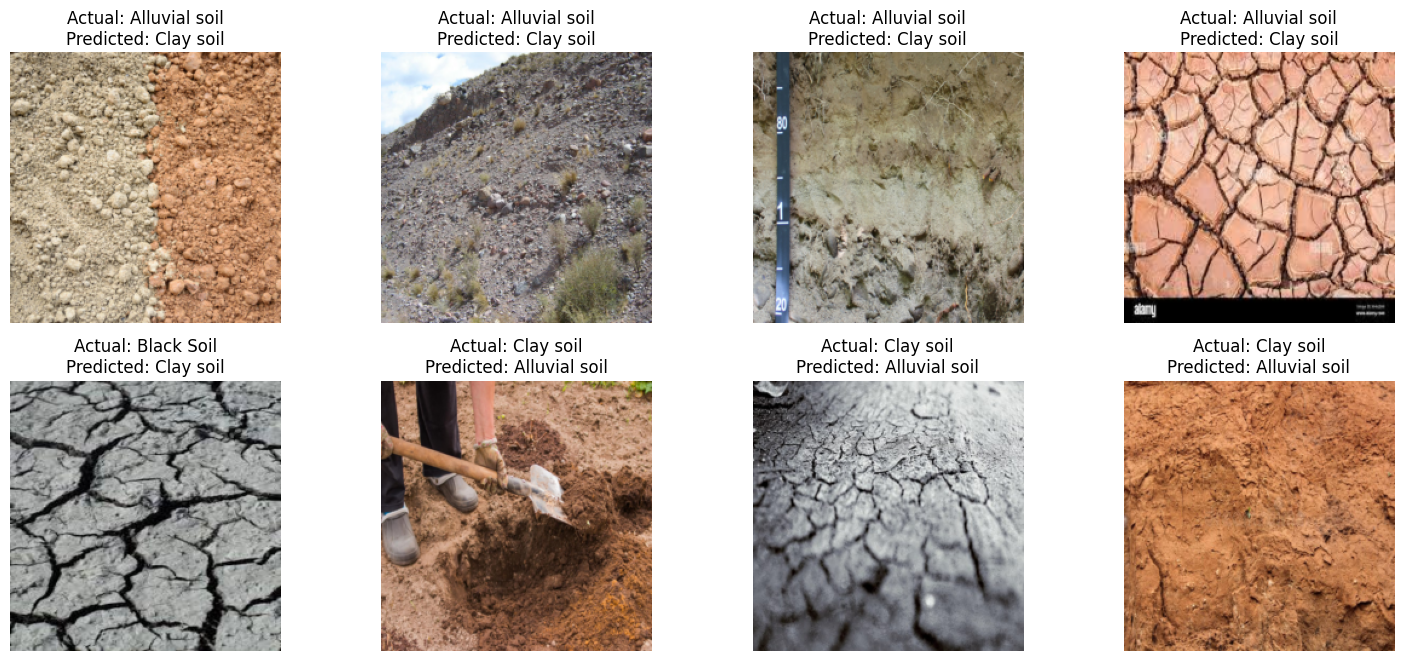

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

num_images = min(12, len(wrong_images))

plt.figure(figsize=(15, 10))

for i in range(num_images):

    img = wrong_images[i]

    # Undo normalization
    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    plt.subplot(3, 4, i + 1)

    plt.imshow(img)

    actual = test_dataset.classes[wrong_labels[i]]
    predicted = test_dataset.classes[wrong_predictions[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

confusions = Counter()

for actual, predicted in zip(all_labels, all_predictions):

    if actual != predicted:

        pair = (
            test_dataset.classes[actual],
            test_dataset.classes[predicted]
        )

        confusions[pair] += 1


print("Misclassification pairs:\n")

for (actual, predicted), count in confusions.items():

    print(
        f"{actual} → {predicted}: {count}"
    )

Misclassification pairs:

Alluvial soil → Clay soil: 4
Black Soil → Clay soil: 1
Clay soil → Alluvial soil: 3


In [ ]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
target_layers = [model.layer4[-1]]

In [ ]:
target_layers = [model.layer4[-1]]

print(target_layers)

[Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)]


In [ ]:
model.eval()

image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    prediction = torch.argmax(output, dim=1).item()

print("Actual:", test_dataset.classes[label])
print("Predicted:", test_dataset.classes[prediction])

Actual: Alluvial soil
Predicted: Alluvial soil


In [ ]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(prediction)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print("Grad-CAM generated successfully")

Grad-CAM generated successfully


In [ ]:
# Check the Grad-CAM values
print("CAM minimum:", grayscale_cam.min())
print("CAM maximum:", grayscale_cam.max())
print("CAM mean:", grayscale_cam.mean())

CAM minimum: 0.0
CAM maximum: 0.9999999
CAM mean: 0.2572278


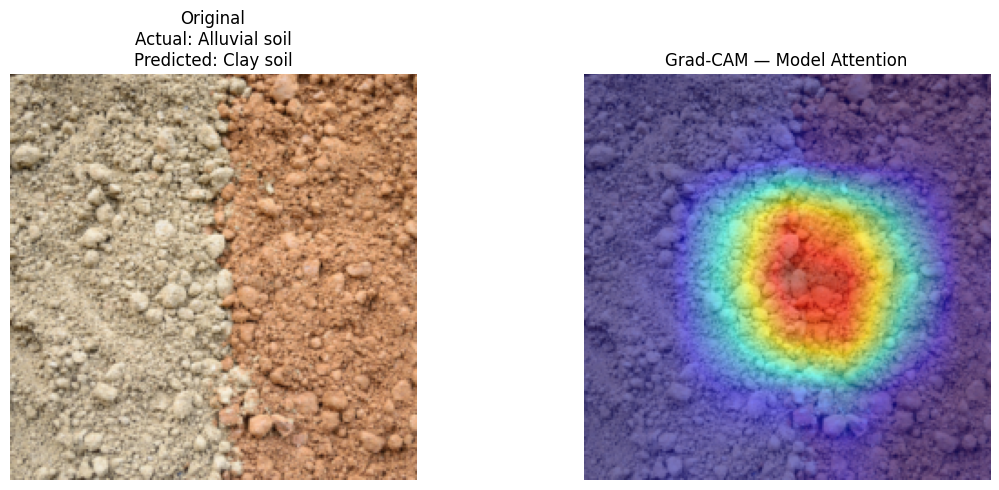

In [ ]:
# Select the first misclassified image
image = wrong_images[0]
actual = wrong_labels[0]
predicted = wrong_predictions[0]

input_tensor = image.unsqueeze(0).to(device)

# Generate Grad-CAM
cam = GradCAM(
    model=model,
    target_layers=[model.layer4[-1]]
)

targets = [ClassifierOutputTarget(predicted)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

# Undo ImageNet normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

rgb_img = image.permute(1, 2, 0).cpu().numpy()
rgb_img = rgb_img * std + mean
rgb_img = np.clip(rgb_img, 0, 1)

# Create heatmap overlay
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(
    f"Original\n"
    f"Actual: {test_dataset.classes[actual]}\n"
    f"Predicted: {test_dataset.classes[predicted]}"
)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM — Model Attention")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "/content/soil_dataset/resnet50_finetuned_final.pth")

In [ ]:
import os

model_path = "/content/soil_dataset/resnet50_finetuned_final.pth"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Size:", os.path.getsize(model_path) / (1024 * 1024), "MB")

Exists: True
Size: 90.0159044265747 MB


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

drive_folder = "/content/drive/MyDrive/AI_Soil_Analytics/models"

os.makedirs(drive_folder, exist_ok=True)

print("Folder created:", drive_folder)

Folder created: /content/drive/MyDrive/AI_Soil_Analytics/models


In [ ]:
import shutil

shutil.copy(
    "/content/soil_dataset/resnet50_finetuned_final.pth",
    "/content/drive/MyDrive/AI_Soil_Analytics/models/resnet50_finetuned_final.pth"
)

print("Final model backed up to Google Drive.")

Final model backed up to Google Drive.


In [ ]:
shutil.copy(
    "/content/soil_dataset/resnet50_results.txt",
    "/content/drive/MyDrive/AI_Soil_Analytics/models/resnet50_results.txt"
)

shutil.copy(
    "/content/soil_dataset/resnet50_training_history.json",
    "/content/drive/MyDrive/AI_Soil_Analytics/models/resnet50_training_history.json"
)

'/content/drive/MyDrive/AI_Soil_Analytics/models/resnet50_training_history.json'